# Does Washington have enough solar and wind potential to meet its electricity demand?

### Demand: hourly county load

Estimated hourly electricity demand for every county in the contiguous US, 2016–2023
(https://data.openei.org/submissions/8562). Each column is one county
(FIPS code with a `p` in front, WA FIPS code starts with p53) and each value is that hour's demand in MW, which is the same as MWh for one hour.

The timestamps are stored in **UTC**, and the file ends at 2023-12-31 23:00 UTC, so "2023" here means the UTC year.

In [1]:
# Block 1: gets the hourly power usage for Washington in 2023

import numpy as np
import pandas as pd
import h5py
import fsspec
from pathlib import Path

url = "https://data.openei.org/files/8562/historic_load_hourly_2016_2023_county.h5"
hourly_csv = Path("data/wa_demand_hourly_2023.csv")
monthly_csv = Path("data/wa_demand_monthly_2023.csv")
Path("data").mkdir(exist_ok=True)

# if we already downloaded the data, just read the saved file
if hourly_csv.exists():
    wa_df = pd.read_csv(hourly_csv, parse_dates=["timestamp"])
else:
    with fsspec.open(url, "rb") as remote_file:
        with h5py.File(remote_file, "r") as hdf_file:
            electricity_data = hdf_file["data"]
            # get the county codes
            county_codes = electricity_data["axis0"][:].astype(str)
            # get timestamps to convert to readable format (they are stored in UTC)
            raw_timestamps = electricity_data["axis1"][:]
            readable_timestamps = pd.to_datetime(raw_timestamps, utc=True)
            # get demand values where rows are hours and columns are counties
            demand = electricity_data["block0_values"]

            # get all Washington State columns (FIPS codes starting with 53)
            wa_indices = [i for i, code in enumerate(county_codes) if code.startswith("p53")]
            # filter the timestamps down to 2023
            time_df = pd.DataFrame({"timestamp": readable_timestamps})
            time_df = time_df[time_df["timestamp"].dt.year == 2023]

            # only read the 2023 rows instead of all 8 years, since the whole file is 1.7 GB
            first_row = time_df.index[0]
            last_row = time_df.index[-1]
            wa_values = demand[first_row:last_row + 1, wa_indices]

            # sum all counties per hour
            wa_demand = wa_values.sum(axis=1)

    # new dataframe with timestamps and power demand
    wa_df = pd.DataFrame({
        "timestamp": time_df["timestamp"],
        "demand_MWh": wa_demand
    })
    wa_df.to_csv(hourly_csv, index=False)

# add up the demand for each month
wa_df["month"] = wa_df["timestamp"].dt.month
monthly_df = wa_df.groupby("month")["demand_MWh"].sum().reset_index()
monthly_df.to_csv(monthly_csv, index=False)

print(wa_df.head(10))
print(f"\nTotal hours of data: {len(wa_df)}")
print(f"Date range: {wa_df.timestamp.min()} to {wa_df.timestamp.max()}")
print(f"Total demand in 2023 (MWh): {wa_df.demand_MWh.sum():,.0f}")
print(f"Average hourly demand (MWh): {wa_df.demand_MWh.mean():,.1f}")
print(f"\nMonthly demand (MWh):\n{monthly_df.to_string(index=False, float_format='{:,.0f}'.format)}")



                  timestamp    demand_MWh  month
0 2023-01-01 00:00:00+00:00  11419.435791      1
1 2023-01-01 01:00:00+00:00  11896.280561      1
2 2023-01-01 02:00:00+00:00  12268.940113      1
3 2023-01-01 03:00:00+00:00  12068.285503      1
4 2023-01-01 04:00:00+00:00  11728.389854      1
5 2023-01-01 05:00:00+00:00  11369.985563      1
6 2023-01-01 06:00:00+00:00  11007.229155      1
7 2023-01-01 07:00:00+00:00  10567.563319      1
8 2023-01-01 08:00:00+00:00  10203.295923      1
9 2023-01-01 09:00:00+00:00   9910.444719      1

Total hours of data: 8760
Date range: 2023-01-01 00:00:00+00:00 to 2023-12-31 23:00:00+00:00
Total demand in 2023 (MWh): 90,720,246
Average hourly demand (MWh): 10,356.2

Monthly demand (MWh):
 month  demand_MWh
     1   8,760,367
     2   8,110,619
     3   8,365,305
     4   7,273,809
     5   6,891,751
     6   6,708,034
     7   7,353,219
     8   7,365,870
     9   6,406,546
    10   7,024,893
    11   7,953,765
    12   8,506,069


### Existing generation: EIA API

Monthly net generation for Washington in 2023 from the EIA's
[electric-power-operational-data](https://www.eia.gov/opendata/browser/electricity/electric-power-operational-data) dataset.
Fuel type ids: `SUN` = solar, `WND` = wind, `HYC` = conventional hydroelectric (not pumped storage), and `ALL` = all fuels,
which we only use to check our numbers against EIA's published total.

EIA returns a row for each sector *and* for subtotals, so we only ask for sector `99`, All Sectors.
Reports are generated in **thousand MWh**, so we multiply by 1000.

You need a free [EIA API key](https://www.eia.gov/opendata/register.php) in a `.env` file only if `data/wa_generation_monthly_2023.csv` is missing.

In [2]:
# Block 2: gets existing solar, wind, and hydro generation in Washington for each month of 2023

import os
import requests
from dotenv import load_dotenv # load environment variables from a .env file

generation_csv = Path("data/wa_generation_monthly_2023.csv")

# From EIA - electricity generation by state and fuel type
eia_url = "https://api.eia.gov/v2/electricity/electric-power-operational-data/data/"

def get_eia_generation(state, fuel_type):
    params = {
        "frequency": "monthly",
        "data[0]": "generation",
        "facets[location][]": state,
        "facets[fueltypeid][]": fuel_type,
        # sector 99 is "all sectors". without this, EIA also returns subtotals and we'd count things more than once
        "facets[sectorid][]": "99",
        "start": "2023-01",
        "end": "2023-12",
    }
    # send the key in a header instead of the url
    response = requests.get(eia_url, params=params, headers={"X-Api-Key": EIA_API_KEY})
    data = response.json()
    rows = data.get("response", {}).get("data", [])
    return pd.DataFrame(rows)

# if we already downloaded the data, just read the saved file
if generation_csv.exists():
    gen_df = pd.read_csv(generation_csv)
else:
    # load the API key from the .env file
    load_dotenv()
    EIA_API_KEY = os.getenv("EIA_API_KEY")

    # SUN = solar, WND = wind, HYC = conventional hydro, ALL = all fuels (to compare with EIA's total)
    dfs = []
    for fuel_type in ["SUN", "WND", "HYC", "ALL"]:
        dfs.append(get_eia_generation("WA", fuel_type))
    gen_df = pd.concat(dfs, ignore_index=True)

    # EIA reports thousand MWh, so we multiply by 1000 to get MWh
    gen_df["generation_MWh"] = pd.to_numeric(gen_df["generation"]) * 1000
    gen_df = gen_df[["period", "fueltypeid", "generation", "generation-units", "generation_MWh"]]
    gen_df.to_csv(generation_csv, index=False)

print("Units from EIA:", gen_df["generation-units"].unique())

# one row per month, one column per fuel type
gen_monthly = gen_df.pivot_table(index="period", columns="fueltypeid", values="generation_MWh")
gen_monthly = gen_monthly.rename(columns={"SUN": "solar_MWh", "WND": "wind_MWh", "HYC": "hydro_MWh", "ALL": "all_fuels_MWh"})
gen_monthly = gen_monthly[["solar_MWh", "wind_MWh", "hydro_MWh", "all_fuels_MWh"]]

print(f"\nMonthly generation (MWh):\n{gen_monthly.to_string(float_format='{:,.0f}'.format)}")
print(f"\n2023 totals (MWh):\n{gen_monthly.sum().to_string(float_format='{:,.0f}'.format)}")
print("\nEIA's published 2023 total for WA: 102,960,605 MWh")
print("(https://www.eia.gov/electricity/state/archive/2023/washington/)")

Units from EIA: ['thousand megawatthours']

Monthly generation (MWh):
fueltypeid  solar_MWh  wind_MWh  hydro_MWh  all_fuels_MWh
period                                                   
2023-01        14,032   567,369  5,720,031      9,543,596
2023-02        22,301   860,349  4,860,724      8,507,351
2023-03        33,866   814,079  4,378,383      8,761,363
2023-04        41,995   767,337  3,782,601      7,402,810
2023-05        16,839   520,450  8,633,211      9,702,359
2023-06        52,846   660,072  5,772,842      7,915,746
2023-07        53,632   651,431  5,412,214      9,249,290
2023-08        45,708   663,266  5,334,251      9,467,615
2023-09        35,155   657,211  3,378,548      7,337,226
2023-10        26,615   398,358  3,756,960      7,533,292
2023-11        14,602   512,892  5,083,478      8,613,807
2023-12         6,725   476,825  5,332,605      8,926,150

2023 totals (MWh):
fueltypeid
solar_MWh           364,316
wind_MWh          7,549,639
hydro_MWh        61,445,849
all

### Potential: EPA RE-Powering Mapper

The EPA's [RE-Powering America's Land](https://www.epa.gov/re-powering) program screens contaminated lands, landfills, and mine sites
for renewable energy. Its mapper has a solar layer (`EstPVCap`, estimated solar capacity in MW) and a wind layer (`EstWindCap`, MW).
We ask for Washington sites only.

**Hanford** is listed 5 times (the whole facility plus 4 cleanup areas), and every row has the full 358,400 acres, so we keep only one.

**Potential generation** = capacity (MW) × capacity factor × 8,760 hours. A capacity factor is how much a plant actually
produces compared to running at full power all year. We use the 2023 US averages for utility-scale plants from
[EIA Electric Power Monthly, Table 6.07.B](https://www.eia.gov/electricity/monthly/epm_table_grapher.php?t=epmt_6_07_b):
**23.2% for solar PV** and **33.2% for wind**. Washington gets less sun than the US average, so the solar number is probably a bit high.

In [3]:
# Block 3: finds locations for solar and wind farms in Washington and their estimated capacity

# EPA RE-Powering Mapper ArcGIS REST API - solar and wind layers
# contains locations pre-screened by the EPA as suitable for renewable energy sites
# an interactive map can be found at https://geopub.epa.gov/repoweringApp/?page=Page-1$0
solar_url = "https://geopub.epa.gov/ArcGIS/rest/services/OLEM/RePM/MapServer/0/query"
wind_url = "https://geopub.epa.gov/ArcGIS/rest/services/OLEM/RePM/MapServer/1/query"
params = {
    "where": "State = 'WA'",
    "outFields": "*",
    "returnGeometry": "false",
    "f": "json"
}
solar_csv = Path("data/wa_epa_solar_sites.csv")
wind_csv = Path("data/wa_epa_wind_sites.csv")

# Keep only columns related to our question
solar_useful_columns = [
    'SiteName',
    'State',
    'Address',
    'City',
    'Acres',
    'DNI',
    'EstPVCap',     # estimated solar panel capacity in MW
]
wind_useful_columns = [
    'SiteName',
    'State',
    'Address',
    'City',
    'Acres',
    'WS80m',        # wind speed at standard height
    'EstWindCap',   # estimated wind capacity in MW
]

def get_epa_sites(url):
    sites = []
    while True:
        # the server only sends up to 1000 sites at a time, so start where the last request left off
        params["resultOffset"] = len(sites)
        response = requests.get(url, params=params)
        data = response.json()
        sites += [f["attributes"] for f in data.get("features", [])]
        # keep asking until the server stops saying there are more sites
        if not data.get("exceededTransferLimit"):
            break
    return pd.DataFrame(sites)

# if we already downloaded the data, just read the saved files
if solar_csv.exists() and wind_csv.exists():
    solar_df = pd.read_csv(solar_csv)
    wind_df = pd.read_csv(wind_csv)
else:
    solar_df = get_epa_sites(solar_url)[solar_useful_columns]
    wind_df = get_epa_sites(wind_url)[wind_useful_columns]
    solar_df.to_csv(solar_csv, index=False)
    wind_df.to_csv(wind_csv, index=False)

clean_solar_df = solar_df.copy()
clean_wind_df = wind_df.copy()

# get rid of any locations that don't have a size since we need that for our calculations
clean_solar_df = clean_solar_df.dropna(subset=['Acres'])
clean_wind_df = clean_wind_df.dropna(subset=['Acres'])

# if any locations don't have the estimated power capacity, fill it in with 0
clean_solar_df['EstPVCap'] = clean_solar_df['EstPVCap'].fillna(0)
clean_wind_df['EstWindCap'] = clean_wind_df['EstWindCap'].fillna(0)

# Hanford is listed 5 times (the whole facility plus 4 cleanup areas) and every row has the full 358,400 acres,
# so keep only the row for the whole facility
hanford_areas = clean_solar_df['SiteName'].str.contains('HANFORD') & (clean_solar_df['SiteName'] != 'US DEPT OF ENERGY HANFORD FACILITY')
clean_solar_df = clean_solar_df[~hanford_areas]

print(f"Solar sites in Washington State: {len(clean_solar_df)}")
print(f"Total available acres: {clean_solar_df['Acres'].sum():,.1f}")
print(f"Total estimated PV capacity (MW): {clean_solar_df['EstPVCap'].sum():,.1f}")

print(f"\nWind sites in Washington State: {len(clean_wind_df)}")
print(f"Total available acres: {clean_wind_df['Acres'].sum():,.1f}")
print(f"Total estimated wind capacity (MW): {clean_wind_df['EstWindCap'].sum():,.1f}")

Solar sites in Washington State: 392
Total available acres: 981,356.0
Total estimated PV capacity (MW): 124,125.2

Wind sites in Washington State: 16
Total available acres: 24,812.7
Total estimated wind capacity (MW): 448.1


In [4]:
# Block 4: calculate annual power production from potential solar and wind sites

# capacity factors: how much a plant actually produces compared to running at full power all year
# 2023 US averages for utility-scale plants from EIA Electric Power Monthly, Table 6.07.B
# https://www.eia.gov/electricity/monthly/epm_table_grapher.php?t=epmt_6_07_b
solar_capacity_factor = 0.232
wind_capacity_factor = 0.332
hours_per_year = 8760

# MW x capacity factor x hours in a year = MWh per year
potential_solar_MWh = clean_solar_df['EstPVCap'].sum() * solar_capacity_factor * hours_per_year
potential_wind_MWh = clean_wind_df['EstWindCap'].sum() * wind_capacity_factor * hours_per_year
potential_total_MWh = potential_solar_MWh + potential_wind_MWh

# Hanford (nuclear cleanup site) and the Yakima Training Center (active Army range) are most of the solar capacity,
# but neither is likely to be covered in panels, so also calculate the potential without them
big_sites = clean_solar_df['SiteName'].str.contains('HANFORD|YAKIMA TRAINING')
potential_solar_excl_MWh = clean_solar_df.loc[~big_sites, 'EstPVCap'].sum() * solar_capacity_factor * hours_per_year
potential_excl_total_MWh = potential_solar_excl_MWh + potential_wind_MWh

print(f"Potential solar (MWh/year): {potential_solar_MWh:,.0f}")
print(f"Potential wind (MWh/year): {potential_wind_MWh:,.0f}")
print(f"Potential total (MWh/year): {potential_total_MWh:,.0f}")
print(f"\n2023 demand (MWh): {wa_df.demand_MWh.sum():,.0f}")
print(f"Potential is {potential_total_MWh / wa_df.demand_MWh.sum():.1f}x Washington's 2023 demand")
print(f"\nHanford and Yakima share of solar capacity: {clean_solar_df.loc[big_sites, 'EstPVCap'].sum() / clean_solar_df['EstPVCap'].sum():.0%}")
print(f"Potential without Hanford and Yakima (MWh/year): {potential_excl_total_MWh:,.0f}")
print(f"Potential without Hanford and Yakima is {potential_excl_total_MWh / wa_df.demand_MWh.sum():.0%} of Washington's 2023 demand")

Potential solar (MWh/year): 252,262,228
Potential wind (MWh/year): 1,303,189
Potential total (MWh/year): 253,565,417

2023 demand (MWh): 90,720,246
Potential is 2.8x Washington's 2023 demand

Hanford and Yakima share of solar capacity: 92%
Potential without Hanford and Yakima (MWh/year): 22,422,896
Potential without Hanford and Yakima is 25% of Washington's 2023 demand


### Results

                                         Demand  Hydro  Wind  Solar  Total Share of demand
2023 demand                               90.72   0.00  0.00   0.00  90.72            100%
Existing solar, wind\n& hydro (2023)       0.00  61.45  7.55   0.36  69.36             76%
Potential solar\n& wind (all EPA sites)    0.00   0.00  1.30 252.26 253.57            280%
Potential without\nHanford & Yakima        0.00   0.00  1.30  21.12  22.42             25%


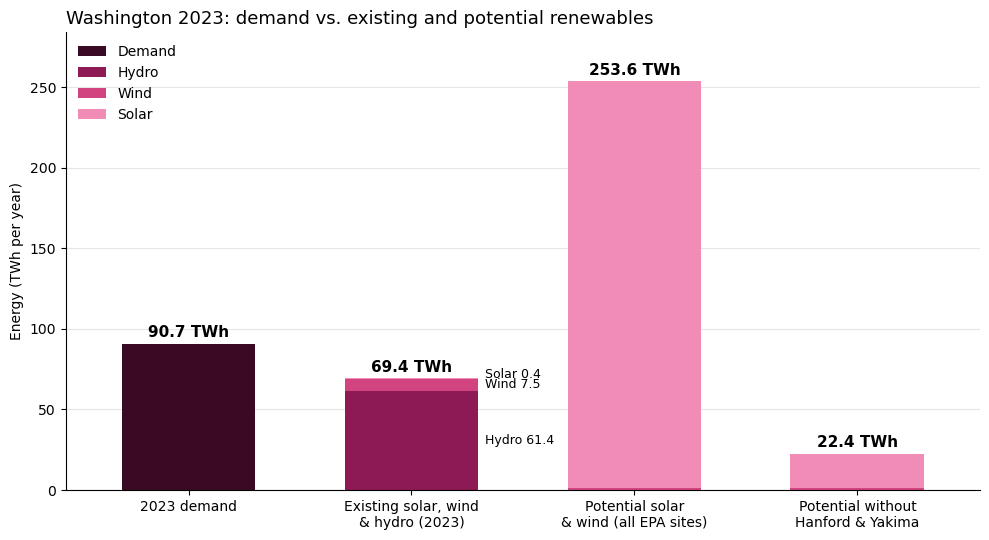

In [5]:
# Block 5: compare 2023 demand to existing and potential generation for the whole year

import matplotlib.pyplot as plt

hydro_color = "#8E1A55"
wind_color = "#D2447F"
solar_color = "#F08CB6"
demand_color = "#3A0A24"

# yearly totals, converted from MWh to TWh (1 TWh = 1,000,000 MWh) so the numbers are easier to read
demand_TWh = wa_df["demand_MWh"].sum() / 1e6
existing_hydro_TWh = gen_monthly["hydro_MWh"].sum() / 1e6
existing_wind_TWh = gen_monthly["wind_MWh"].sum() / 1e6
existing_solar_TWh = gen_monthly["solar_MWh"].sum() / 1e6
potential_wind_TWh = potential_wind_MWh / 1e6
potential_solar_TWh = potential_solar_MWh / 1e6
potential_solar_excl_TWh = potential_solar_excl_MWh / 1e6

# one row per bar, one column per stacked piece
annual_df = pd.DataFrame({
    "Demand": [demand_TWh, 0, 0, 0],
    "Hydro": [0, existing_hydro_TWh, 0, 0],
    "Wind": [0, existing_wind_TWh, potential_wind_TWh, potential_wind_TWh],
    "Solar": [0, existing_solar_TWh, potential_solar_TWh, potential_solar_excl_TWh],
}, index=["2023 demand", "Existing solar, wind\n& hydro (2023)", "Potential solar\n& wind (all EPA sites)",
          "Potential without\nHanford & Yakima"])

annual_df["Total"] = annual_df.sum(axis=1)
annual_df["Share of demand"] = (annual_df["Total"] / demand_TWh).map("{:.0%}".format)
print(annual_df.to_string(float_format="{:,.2f}".format))

# stacked bar chart
ax = annual_df[["Demand", "Hydro", "Wind", "Solar"]].plot(
    kind="bar", stacked=True, rot=0, width=0.6, figsize=(10, 5.5),
    # no white outline here, since it covers up the thin pieces (like potential wind) and shows a white line under empty ones
    color=[demand_color, hydro_color, wind_color, solar_color],
)

# label the total on top of each bar
for i, total in enumerate(annual_df["Total"]):
    ax.text(i, total + 4, f"{total:,.1f} TWh", ha="center", fontsize=11, fontweight="bold")

# label the pieces of the existing bar, since solar is too small to see
ax.text(1.33, existing_hydro_TWh / 2, f"Hydro {existing_hydro_TWh:.1f}", va="center", fontsize=9)
ax.text(1.33, existing_hydro_TWh + existing_wind_TWh / 2, f"Wind {existing_wind_TWh:.1f}", va="center", fontsize=9)
ax.text(1.33, existing_hydro_TWh + existing_wind_TWh + 3, f"Solar {existing_solar_TWh:.1f}", va="center", fontsize=9)

ax.set_title("Washington 2023: demand vs. existing and potential renewables", fontsize=13, loc="left")
ax.set_ylabel("Energy (TWh per year)")
ax.set_ylim(0, annual_df["Total"].max() * 1.12)
ax.grid(axis="y", color="#e6e6e6")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig("images/annual_comparison.png", dpi=200)
plt.show()

     Hydro  Wind  Solar  Demand  Renewables total Share of demand
Jan   5.72  0.57   0.01    8.76              6.30             72%
Feb   4.86  0.86   0.02    8.11              5.74             71%
Mar   4.38  0.81   0.03    8.37              5.23             62%
Apr   3.78  0.77   0.04    7.27              4.59             63%
May   8.63  0.52   0.02    6.89              9.17            133%
Jun   5.77  0.66   0.05    6.71              6.49             97%
Jul   5.41  0.65   0.05    7.35              6.12             83%
Aug   5.33  0.66   0.05    7.37              6.04             82%
Sep   3.38  0.66   0.04    6.41              4.07             64%
Oct   3.76  0.40   0.03    7.02              4.18             60%
Nov   5.08  0.51   0.01    7.95              5.61             71%
Dec   5.33  0.48   0.01    8.51              5.82             68%


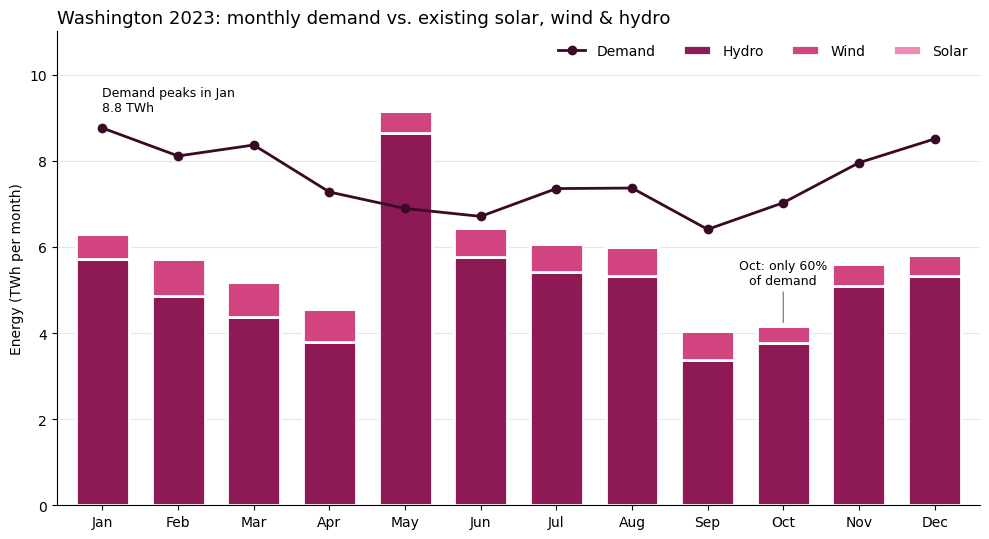

In [6]:
# Block 6: compare demand to existing solar, wind, and hydro for each month of 2023

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# one row per month, converted from MWh to TWh
monthly_compare = pd.DataFrame({
    "Hydro": gen_monthly["hydro_MWh"].values / 1e6,
    "Wind": gen_monthly["wind_MWh"].values / 1e6,
    "Solar": gen_monthly["solar_MWh"].values / 1e6,
}, index=month_names)
monthly_compare["Demand"] = monthly_df["demand_MWh"].values / 1e6

# how much of each month's demand the existing solar, wind, and hydro could cover
monthly_compare["Renewables total"] = monthly_compare[["Hydro", "Wind", "Solar"]].sum(axis=1)
monthly_compare["Share of demand"] = (monthly_compare["Renewables total"] / monthly_compare["Demand"]).map("{:.0%}".format)
print(monthly_compare.to_string(float_format="{:,.2f}".format))

# stacked bars for generation
ax = monthly_compare[["Hydro", "Wind", "Solar"]].plot(
    kind="bar", stacked=True, rot=0, width=0.7, figsize=(10, 5.5),
    color=[hydro_color, wind_color, solar_color],
    edgecolor="white", linewidth=2,
)

# line for demand on top
ax.plot(range(12), monthly_compare["Demand"], color=demand_color, linewidth=2, marker="o", markersize=6, label="Demand")

# label the highest and lowest months so the gap is easy to see
peak = monthly_compare["Demand"].idxmax()
low = (monthly_compare["Renewables total"] / monthly_compare["Demand"]).idxmin()
ax.annotate(f"Demand peaks in {peak}\n{monthly_compare.loc[peak, 'Demand']:.1f} TWh",
            (month_names.index(peak), monthly_compare.loc[peak, "Demand"]),
            xytext=(0, 12), textcoords="offset points", ha="left", fontsize=9)
ax.annotate(f"{low}: only {monthly_compare.loc[low, 'Share of demand']}\nof demand",
            (month_names.index(low), monthly_compare.loc[low, "Renewables total"]),
            xytext=(0, 30), textcoords="offset points", ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="-", color="#888888"))

ax.set_title("Washington 2023: monthly demand vs. existing solar, wind & hydro", fontsize=13, loc="left")
ax.set_ylabel("Energy (TWh per month)")
ax.set_ylim(0, monthly_compare[["Demand", "Renewables total"]].max().max() * 1.2)
ax.grid(axis="y", color="#e6e6e6")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper right", ncol=4)

plt.tight_layout()
plt.savefig("images/monthly_comparison.png", dpi=200)
plt.show()

### Conclusion

**Not from these EPA sites alone, but Washington is already most of the way there.**

- **Existing renewables cover about three quarters of demand.** Hydro, wind, and solar made 69.4 TWh in 2023, or 76% of the 90.7 TWh the state used. Hydro is 61.4 TWh of that.
- **The EPA sites only look big because of two sites.** All 392 sites add up to 253.6 TWh a year (2.8x demand), but Hanford and the Yakima Training Center are 92% of the solar capacity, and neither is likely to be covered in panels. Without them, the potential is 22.4 TWh, or 25% of demand.
- **The gap changes a lot by month.** Existing renewables covered 133% of demand in May, when snowmelt fills the rivers, but only 60% in October. Winter has the highest demand and the least sun, so solar can't fill that gap on its own.
- **On paper it adds up, barely.** Existing renewables plus the EPA sites without Hanford and Yakima come to about 92 TWh, just over one year of demand. That only works with storage or trading to move summer solar into winter, and the solar numbers are probably high (see Limitations).


### Limitations

- **Capacity factors are national averages.** We use the 2023 US averages (23.2% solar, 33.2% wind). Washington gets less sun than the US average, so the solar potential is probably too high.
- **EPA sites are a specific kind of land.** The RE-Powering program only screens contaminated lands, landfills, and mine sites, so this isn't all the land in Washington that could hold solar or wind. The capacities are EPA screening estimates based on acreage, not engineering studies.
- **Removing Hanford and Yakima is a judgment call.** Some of that land could hold solar, so the real potential is probably somewhere between the two estimates (22.4 and 253.6 TWh).
- **No storage or transmission.** We compare energy totals only. We don't model batteries, moving power around the state or between states, or whether the grid can connect these sites.
- **No hourly or monthly potential yet.** The monthly chart only shows *existing* generation. Solar is weakest in winter when demand is highest, but we don't model how the potential sites would produce month to month.
- **Demand is an estimate.** The county demand data is modeled from utility-area data and scaled to annual retail sales, and it is in UTC, so months are shifted by 8 hours from Pacific time.
- **Existing solar is utility-scale only.** EIA's `SUN` numbers don't include rooftop solar. EIA's monthly solar number for May 2023 also looks unusually low compared to April and June.
- **Washington trades power with other states.** Generating more than demand over a year doesn't mean every kilowatt-hour stays in the state.